<a href="https://colab.research.google.com/github/gien-7/progetto_GraphColouring_ML26/blob/main/Notebook_GNN_v0_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os

repo_name = 'progetto_GraphColouring_ML26'
repo_url = 'https://github.com/gien-7/progetto_GraphColouring_ML26.git'

if not os.path.exists(repo_name):
    !git clone {repo_url}
else:
    print(f"La cartella '{repo_name}' è già caricata")

Cloning into 'progetto_GraphColouring_ML26'...
remote: Enumerating objects: 34, done.
remote: Counting objects: 100% (34/34), done.
remote: Compressing objects: 100% (29/29), done.
remote: Total 34 (delta 10), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (34/34), 240.51 KiB | 5.59 MiB/s, done.
Resolving deltas: 100% (10/10), done.


In [2]:
import warnings
warnings.filterwarnings("ignore", category=SyntaxWarning)

**Leggiamo i dati, controlliamo il formato (shape) e ne stampiamo la struttura**



In [3]:
import pandas as pd

file1 = 'progetto_GraphColouring_ML26/g6.col'  # queen9x9
file2 = 'progetto_GraphColouring_ML26/g17.col'  # miles750

df_g6 = pd.read_csv(file1, sep='\s+', skiprows=4, usecols=[1,2], names=['node1','node2'])
df_g17 = pd.read_csv(file2, sep='\s+', skiprows=4, usecols=[1,2], names=['node1','node2'])

print('Shape g6.col  : ',df_g6.shape)
print('Shape g17.col : ',df_g17.shape)

Shape g6.col  :  (2112, 2)
Shape g17.col :  (4226, 2)


In [4]:
print(df_g6)

      node1  node2
0         1     11
1         1     21
2         1     31
3         1     41
4         1     51
...     ...    ...
2107     81     21
2108     81     18
2109     81     11
2110     81      9
2111     81      1

[2112 rows x 2 columns]


In [27]:
df_g6[df_g6.columns] - 1

,node1,node2
0,0,10
1,0,20
2,0,30
3,0,40
4,0,50
...,...,...
2107,80,20
2108,80,17
2109,80,10
2110,80,8


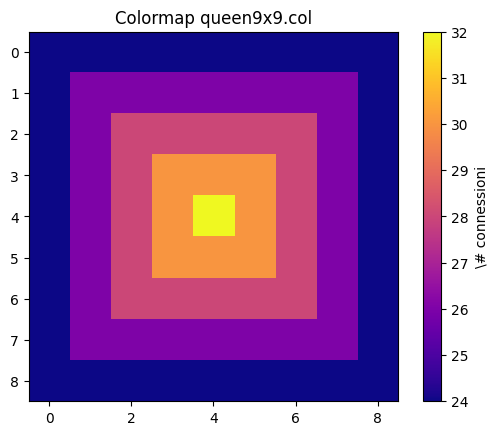

In [5]:
import numpy as np
import matplotlib.pyplot as plt

unique, counts = np.unique(df_g6['node1'].values, return_counts=True)  # non cambierebbe nulla se operassi invece su node2 per simmetria
intensity = counts.reshape(9,9)

plt.imshow(intensity, cmap='plasma')
plt.colorbar(label = '\# connessioni')
plt.title('Colormap queen9x9.col')
plt.show()

**Data augmentation sfruttando invarianze del problema**

In [7]:
from torch.utils.data import Dataset, DataLoader
import torch
import torch.utils.data as data

!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 23.7 MB/s eta 0:00:00


In [28]:
from torch_geometric.loader import DataLoader
import torch_geometric.data as Data


def build_edges_from_df(col1, col2):
  src = torch.tensor(col1.values, dtype=torch.long)
  dst = torch.tensor(col2.values, dtype=torch.long)
  edge_index = torch.stack([src, dst], dim=0)
  return edge_index


class GraphGenerator(Dataset):  # Cambiamento rispetto alla CNN: il Dataset ora produce grafi PyG, non immagini.
    def __init__(self, X, y, df):
      super().__init__()
      self.grid = df
      self.X = X  # dati (scacchiera)
      self.y = y  # color

    def __len__(self):  # Ritorna la dimensione del dataset
      return len(self.X)

    def __getitem__(self, idx): #ritorna l'elemento idx del dataset
      intensity = self.X[idx].copy()
      label = self.y[idx].copy()
      board = self.grid[idx].copy()
      col1_label = (self.grid[idx].columns)[0]
      col2_label = (self.grid[idx].columns)[1]

      rows, cols = np.indices((9, 9))
      rows = rows.reshape(-1) # [0,0,0 // 1,1,1 // ... // n,n,n]
      cols = cols.reshape(-1) # [0,1,2...,n // 0,1,2,...,n // ...]
      values = intensity[rows, cols].astype(np.float32)  # sarà unidimensionale avendo flattenato

      # data.pos contiene le coordinate geometriche non normalizzate delle connessioni sul piano 9x9.
      pos = torch.tensor(np.stack([rows, cols], axis=1), dtype=torch.float)
      pos_n = (pos/8)*2 - 1
      value = torch.tensor(values/values.sum(), dtype=torch.float).view(-1, 1)
      x = torch.cat([value, pos], dim=1)  # torch vuole dimensione dummy delle label di x

      # L'output di build_knn_edges del tipo torch.Tensor(2, (num_nodes x k_eff)), interi int64
      edge_index = build_edges_from_df(board[col1_label]-1,board[col2_label]-1)
      # In input le due serie relative al dataframe, scalate di 1 (anzichè fare da 1->9 fa 0->8)

      # Problema unsupervised, uso y dummy pari a indici delle caselle
      tensor_color = torch.arange(81, dtype=torch.long)

      return Data(x=x, edge_index=edge_index, y=tensor_color, pos=pos_n)

In [10]:
#MODIFICARE, CONTESTO DI GRAPH AUGMENTATION

def RotateGraph(graph, theta):
    return np.rot90(graph, k=theta)

def FlipHorizontalGraph(graph):
    return np.fliplr(graph)

def FlipVerticalGraph(graph):
    return np.flipud(graph)

def TransposeGraph(graph):
    return np.transpose(graph)

**Splitting del dataset**

In [11]:
from sklearn.model_selection import train_test_split

X, X_val, y, y_val = train_test_split(x_all, y_all, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_val, y_val, test_size=0.5, random_state=42)

print('Shape X_train : ',X.shape)
print('Shape X_val   : ',X_val.shape)
print('Shape X_test  : ',X_test.shape)

NameError: name 'x_all' is not defined